# Helmholtz equation for TM modes in a pillbox cavity

Solve the Helmholtz equation for TM modes:

\[
\nabla^2 u + k^2 u = 0 \quad\text{in }\Omega
\]

with \(\Omega\) being a circular pillbox cavity, Dirichlet boundary \(u=0\) on the boundary.

We'll find the eigenvalues \(k^2\) and corresponding modes, including TM010.

1. Build a gmsh mesh of the circular domain.
2. Read into dolfinx and solve eigenvalue problem with SLEPc.
3. Visualize with pyvista.

In [35]:
# If you need to install packages in a notebook environment, uncomment and run.
# Be careful: installing dolfinx in-notebook is not trivial on every system.
# !pip install gmsh meshio pyvista meshio-xdmf pyvistaqt

# Imports

import gmsh

import numpy as np
from mpi4py import MPI

import dolfinx
import meshio
from dolfinx import mesh as dmesh
from dolfinx import *
from dolfinx.fem import  dirichletbc, locate_dofs_topological
from dolfinx.mesh import locate_entities_boundary
from dolfinx.io import XDMFFile
import ufl
from petsc4py import PETSc
from slepc4py import SLEPc

from dolfinx.fem.petsc import assemble_matrix, assemble_vector, apply_lifting, set_bc

# Visualization
import pyvista as pv

In [36]:
# Geometry parameters for pillbox cavity
R = 1.0  # Radius of the pillbox
center = [0.0, 0.0, 0.0]

gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.model.add("pillbox")

# Set global mesh size (uniform)
mesh_size = 0.05  # Adjust this value: smaller = more mesh points/finer mesh
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)

# Create disk using OpenCASCADE
disk = gmsh.model.occ.addDisk(center[0], center[1], center[2], R, R)

gmsh.model.occ.synchronize()

# Physical group for the surface
gmsh.model.addPhysicalGroup(2, [disk], tag=1)
gmsh.model.setPhysicalName(2, 1, "Domain")

# Physical group for the boundary (circle)
boundaries = gmsh.model.getBoundary([(2, disk)], oriented=False)
boundary_tags = [b[1] for b in boundaries]
gmsh.model.addPhysicalGroup(1, boundary_tags, tag=2)
gmsh.model.setPhysicalName(1, 2, "Boundary")

# Generate mesh (2D triangular)
gmsh.model.mesh.generate(2)

# Save mesh
msh_filename = "pillbox.msh"
gmsh.write(msh_filename)
print(f"Saved mesh to {msh_filename}")

# finalize gmsh
gmsh.finalize()

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 6.1125e-05s, CPU 8.6e-05s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0382877s, CPU 0.044003s)
Info    : 1550 nodes 3099 elements
Info    : Writing 'pillbox.msh'...
Saved mesh to pillbox.msh
Info    : Done writing 'pillbox.msh'


In [37]:
from dolfinx.io import gmshio

mesh, cell_tags, facet_tags = gmshio.read_from_msh(
    "pillbox.msh",
    MPI.COMM_WORLD,
    gdim=2
)

print("Mesh loaded directly from gmsh:")
print("  cells:", mesh.topology.index_map(mesh.topology.dim).size_local)
print("  vertices:", mesh.topology.index_map(0).size_local)

Info    : Reading 'pillbox.msh'...
Info    : 3 entities
Info    : 1550 nodes
Info    : 3098 elements
Info    : Done reading 'pillbox.msh'
Mesh loaded directly from gmsh:
  cells: 2972
  vertices: 1550


In [38]:
# Function space (first-order Lagrange, CG1)
V = fem.functionspace(mesh, ("CG", 1))

# Trial / Test
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Variational forms for eigenvalue problem
# ∇²u + k²u = 0 ⇒ ∫∇u·∇v dx = k² ∫u v dx
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
b = u * v * ufl.dx

# --- Dirichlet BCs u=0 on boundary ---
facet_indices = facet_tags.find(2)
dofs_zero = locate_dofs_topological(V, mesh.topology.dim - 1, facet_indices)
u_zero = fem.Function(V)
u_zero.x.array[:] = 10.0
bc = dirichletbc(u_zero, dofs_zero)

bcs = [bc]

print("a =", a)
print("b =", b)
print("bcs =", bcs)

a = { (grad(v_1)) . (grad(v_0)) } * dx(<Mesh #4>[everywhere], {})
b = { v_0 * v_1 } * dx(<Mesh #4>[everywhere], {})
bcs = [<dolfinx.fem.bcs.DirichletBC object at 0x32f425340>]


In [39]:
# Assemble matrices
a_form = fem.form(a)
b_form = fem.form(b)

A = assemble_matrix(a_form, bcs=bcs)
A.assemble()
B = assemble_matrix(b_form, bcs=bcs)
B.assemble()

# Solve eigenvalue problem with SLEPc
eps = SLEPc.EPS().create(MPI.COMM_WORLD)
eps.setOperators(A, B)
eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)  # Generalized Hermitian Eigenvalue Problem
eps.setWhichEigenpairs(SLEPc.EPS.Which.SMALLEST_REAL)  # Smallest eigenvalues
eps.setDimensions(nev=10)  # Number of eigenvalues to compute

eps.solve()

nconv = eps.getConverged()
print(f"Number of converged eigenvalues: {nconv}")

eigenvalues = []
eigenfunctions = []

for i in range(min(nconv, 10)):
    lam = eps.getEigenvalue(i)
    eigenvalues.append(lam.real)
    
    # Get eigenvector
    vr, vi = A.createVecs()
    eps.getEigenvector(i, vr, vi)
    
    uh = fem.Function(V)
    uh.x.array[:] = vr.getArray()
    
    eigenfunctions.append(uh)
    
    print(f"Eigenvalue {i}: {lam.real}")

# For visualization, use the first mode
uh = eigenfunctions[0]
sol_array = uh.x.array

Number of converged eigenvalues: 15
Eigenvalue 0: 0.9999999999995595
Eigenvalue 1: 1.0000000000001892
Eigenvalue 2: 1.0000000000036424
Eigenvalue 3: 5.788371921279129
Eigenvalue 4: 14.715391472355314
Eigenvalue 5: 14.71548356728061
Eigenvalue 6: 26.482275053100313
Eigenvalue 7: 26.48281883777125
Eigenvalue 8: 30.61562436227674
Eigenvalue 9: 40.96199756343541


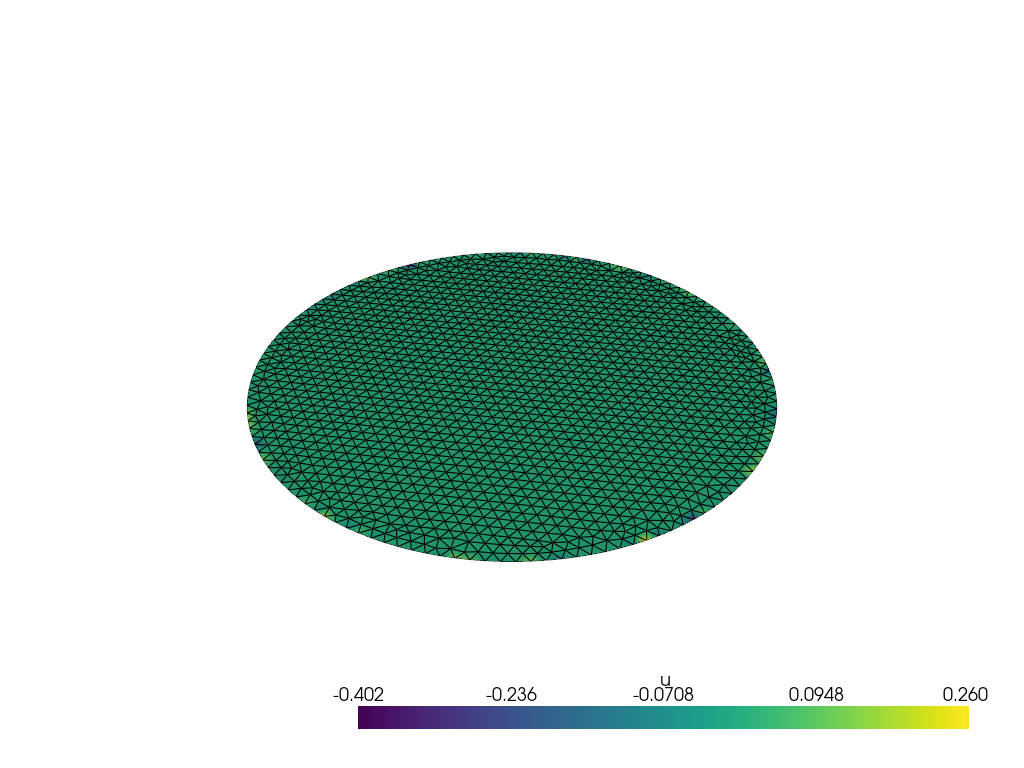

In [40]:
# Visualization with pyvista

# get coordinates (global)
coords = mesh.geometry.x.copy()   # (num_vertices, gdim)
coords = np.array(coords)         # ensure numpy array
num_vertices_per_cell = mesh.topology.dim + 1  # triangles -> 3
# get cell->vertex connectivity for triangles
top = mesh.topology.connectivity(mesh.topology.dim, 0)
conn = top.array.reshape((-1, num_vertices_per_cell))  # cells x num_vertices_per_cell
cells = conn.astype(np.int64)

# build pyvista cell array format
n_cells = cells.shape[0]
cell_types = np.full(n_cells, pv.CellType.TRIANGLE, dtype=np.uint8)
cells_pv = np.hstack([np.full((n_cells, 1), num_vertices_per_cell, dtype=np.int64), cells]).flatten()

grid = pv.UnstructuredGrid(cells_pv, cell_types, coords)
# attach solution at nodal points if number of points matches
if coords.shape[0] == sol_array.shape[0]:
    grid["u"] = sol_array
else:
    # might be cell-wise: attach cell data
    if sol_array.shape[0] == n_cells:
        grid.cell_data["u"] = sol_array
    else:
        print("Mismatch between dofs and points — skip attaching data")

p = pv.Plotter(notebook=True)
p.add_mesh(grid, scalars="u", show_edges=True)
p.add_scalar_bar("u")
p.show()


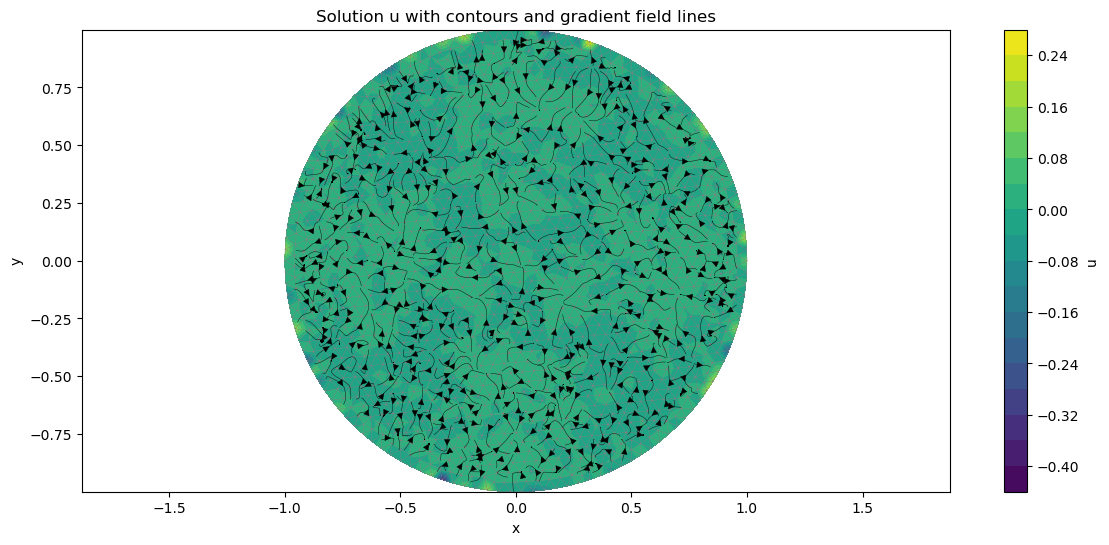

In [41]:
# Visualization with contours and field lines (2D flat plot)

import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Get coordinates
x, y = coords[:, 0], coords[:, 1]

# Compute gradient
from dolfinx.fem import functionspace, Function, Expression
from ufl import grad
W = functionspace(mesh, ('CG', 1, (mesh.geometry.dim,)))
grad_uh = Function(W)
expr = Expression(grad(uh), W.element.interpolation_points())
grad_uh.interpolate(expr)
grad_array = grad_uh.x.array.reshape(-1, mesh.geometry.dim)

# Plot filled contours
plt.figure(figsize=(14, 6))
plt.tricontourf(x, y, cells, sol_array, levels=20, cmap='viridis')
plt.colorbar(label='u')

# Interpolate gradient onto a regular grid for streamplot
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
XI, YI = np.meshgrid(xi, yi)

grad_x_interp = griddata((x, y), grad_array[:, 0], (XI, YI), method='linear')
grad_y_interp = griddata((x, y), grad_array[:, 1], (XI, YI), method='linear')

# Add streamlines for gradient
plt.streamplot(xi, yi, grad_x_interp, grad_y_interp, density=3, color='black', linewidth=0.3)

# Add mesh edges for reference
plt.triplot(x, y, cells, color='gray', linewidth=0.3)
plt.axis('equal')
plt.title('Solution u with contours and gradient field lines')
plt.xlabel('x')
plt.ylabel('y')
plt.show()